### TODO Recording:

- Start with the notebook open
- Copy the code one cell at a time

In [1]:
pip install torch matplotlib numpy pandas

In [2]:
pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.3 MB/s eta 0:00:00


In [3]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing 

In [4]:
pip install pyngrok

In [6]:
get_ipython().system_raw("mlflow ui --port 5000 &")


from pyngrok import ngrok

ngrok.kill()

NGROK_AUTH_TOKEN = "39Hlt66o3EDMiQdxsJlaBA5c6U3_4M47VW64FXsWeuvus8wmZ"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

ngrok_tunnel = ngrok.connect(
    addr="127.0.0.1:5000",
    proto="http",
    host_header="rewrite",
)

print("MLflow Tracking UI:", ngrok_tunnel.public_url)

MLflow Tracking UI: https://41eb-34-87-72-44.ngrok-free.app


### TODO Recording:

- Go to the MLflow UI and show that it is empty

In [7]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

In [8]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [9]:
emnist_train_data  = pd.read_csv("/content/drive/MyDrive/emnist_data/emnist-letters-train.csv", header=None)

emnist_test_data = pd.read_csv("/content/drive/MyDrive/emnist_data/emnist-letters-test.csv", header=None)

In [10]:
class EMNISTDataset(Dataset):
    def __init__(self, dataframe):

        self.images = torch.tensor(dataframe.iloc[:, 1:].values, dtype= torch.float32)

        self.labels = torch.tensor(dataframe.iloc[:, 0].values, dtype = torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        images = self.images[idx]

        images = images / 255.0
        labels = self.labels[idx]

        return images, labels

In [11]:
emnist_test_data = emnist_test_data.sample(frac = 1)

In [12]:
train_dataset = EMNISTDataset(emnist_train_data)

test_dataset = EMNISTDataset(emnist_test_data )

In [13]:
from torch.utils.data import random_split

val_percent = 0.1
val_len = int(val_percent * len(train_dataset))

train_ds, val_ds = random_split(train_dataset, [len(train_dataset) - val_len, val_len])

In [14]:
batch_size = 64

train_dataloader = DataLoader(train_ds, batch_size, shuffle = True, drop_last = True, num_workers=1)

val_dataloader = DataLoader(val_ds, batch_size, num_workers=1)

test_dataloader = DataLoader(test_dataset, batch_size, num_workers=1)

len(train_dataloader), len(val_dataloader), len(test_dataloader)

(1248, 139, 232)

All libraries for model training are imported

In [15]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl

from torchmetrics.functional import accuracy

In [16]:
import mlflow

experiment_id = mlflow.create_experiment(name = "emnist_letters_prediction_using_cnn")

mlflow.set_experiment(experiment_name = "emnist_letters_prediction_using_cnn")

2026/02/09 08:34:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/09 08:34:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/09 08:34:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/09 08:34:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/09 08:34:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/09 08:34:16 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/09 08:34:16 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/09 08:34:16 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1770626056790, experiment_id='1', last_update_time=1770626056790, lifecycle_stage='active', name='emnist_letters_prediction_using_cnn', tags={}>

Defining Lightning Module for Letter classification. Model is CNN and metrics are logged using log method of lightning

In [17]:
class EmnistModel(pl.LightningModule):
    def __init__(self):
        super().__init__()

        self.criterion = nn.CrossEntropyLoss()

        self.network = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64 * 14 * 14

            nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), #256 * 7 * 7

            nn.Flatten(),
            nn.Linear(256*7*7, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 26)
        )

    def forward(self, xb):
        return self.network(xb.reshape(-1, 1, 28, 28))

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr = 0.0001)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y -= 1

        y_hat = self(x)
        loss = self.criterion(y_hat, y.long())
        pred = y_hat.argmax(dim = 1)

        acc = accuracy(pred, y, task = "multiclass", num_classes = 26)

        self.log("train_loss", loss, on_epoch = True, prog_bar = True)
        self.log("train_acc", acc, on_epoch = True, prog_bar = True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y -= 1

        y_hat = self(x)
        loss = self.criterion(y_hat, y.long())
        pred = y_hat.argmax(dim = 1)

        acc = accuracy(pred, y, task = "multiclass", num_classes = 26)

        self.log("valid_loss", loss, on_epoch = True, prog_bar = True)
        self.log("valid_acc", acc, on_epoch = True, prog_bar = True)

        return acc

    def test_step(self, batch, batch_idx):
        x, y = batch
        y -= 1

        y_hat = self(x)
        loss = self.criterion(y_hat, y.long())
        pred = y_hat.argmax(dim = 1)

        acc = accuracy(pred, y, task = "multiclass", num_classes = 26)

        self.log("test_loss", loss, logger = True)
        self.log("test_acc", acc, logger = True)

        return acc


    def predict_step(self, batch, batch_idx, dataloader_idx = 0):
        x, y = batch

        return self(x)

Model Training is done  with Trainer and All parameters are autologged using mlflow autologging and Trained Model is logged separately with defined Signature with input and output schema. Model metrics are also separately logged using CSV logger. Training is done for 10 epochs and then Model is tested on Test dataloader

In [18]:
from mlflow.models.signature import ModelSignature
from mlflow.types.schema import ColSpec, Schema, TensorSpec
from pytorch_lightning.loggers import CSVLogger

emnist_model = EmnistModel()

logger = CSVLogger("logs", name = "emnist_letters_classification_2")

trainer = pl.Trainer(max_epochs = 10, logger = logger)

mlflow.pytorch.autolog(log_models = False)

with mlflow.start_run() as run:

    trainer.fit(emnist_model, train_dataloader, val_dataloader)
    trainer.test(dataloaders = test_dataloader)

    input_schema = Schema([TensorSpec(np.dtype(np.float32), (-1, 1, 28, 28))])
    output_schema = Schema([TensorSpec(np.dtype(np.float32), (-1, 26))])
    signature = ModelSignature(inputs = input_schema, outputs = output_schema)

    mlflow.pytorch.log_model(emnist_model, "emnist-letters-classifier-cnn-model-2", signature = signature)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026/02/09 08:35:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/pytorch/_lightning_autolog.py:542: UserWarning: Autologging is known to be compatible with pytorch-lightning versions between 2.1.4 and 2.6.0 and may not succeed with packages outside this range."
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically w

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ network   │ Sequential       │  793 K │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 793 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 793 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026/02/09 08:36:08 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 
'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored 
metric value is not available.

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at logs/emnist_letters_classification_2/version_0/checkpoints/epoch=9-step=12480.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at logs/emnist_letters_classification_2/version_0/checkpoints/epoch=9-step=12480.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9172973036766052     │
│         test_loss         │    0.25403234362602234    │
└───────────────────────────┴───────────────────────────┘

2026/02/09 08:41:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/09 08:41:24 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/02/09 08:41:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.9.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/09 08:41:40 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.24.0+cu126) contains a local version label (+cu1

### TODO Recording

- Go to the MLflow UI
- Show the new run
- IMPORTANT: Show the charts in the chart tab
- Click through to the run
- Show everything logged
- Click on each artifact under MLmodel

Logged metrics dataframe is obtained

In [19]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

metrics

,epoch,step,test_acc,test_loss,train_acc_epoch,train_acc_step,train_loss_epoch,train_loss_step,valid_acc,valid_loss
0,0,49,NaN,NaN,NaN,0.015625,NaN,3.167330,NaN,NaN
1,0,99,NaN,NaN,NaN,0.343750,NaN,2.287171,NaN,NaN
2,0,149,NaN,NaN,NaN,0.437500,NaN,2.150811,NaN,NaN
3,0,199,NaN,NaN,NaN,0.546875,NaN,1.532686,NaN,NaN
4,0,249,NaN,NaN,NaN,0.656250,NaN,1.188671,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
265,9,12399,NaN,NaN,NaN,0.921875,NaN,0.269808,NaN,NaN
266,9,12449,NaN,NaN,NaN,0.921875,NaN,0.174508,NaN,NaN
267,9,12479,NaN,NaN,NaN,NaN,NaN,NaN,0.925901,0.219839
268,9,12479,NaN,NaN,0.945989,NaN,0.156727,NaN,NaN,NaN


Accuracy and Loss are plotted wrt epochs

<Axes: xlabel='epoch'>

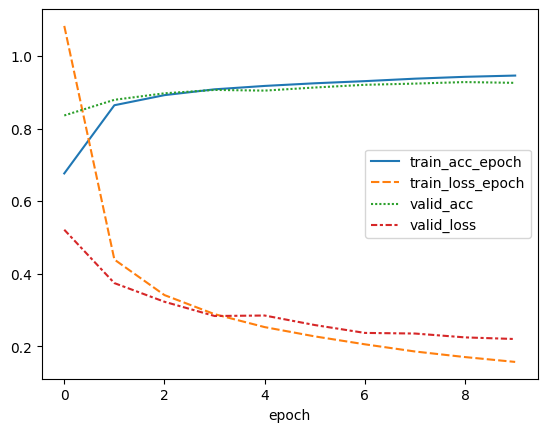

In [20]:
import seaborn as sns

metrics.set_index("epoch", inplace = True)
metrics.drop(columns = ['step', 'train_loss_step',
                        'train_acc_step', 'test_acc', 'test_loss'], inplace = True)

sns.lineplot(data = metrics)

Obtaining last active run id

In [21]:
run_id = mlflow.last_active_run().info.run_id

run_id

'a894f8ef7a8d468982ae96b023c75c83'

Batch of test images are loaded

In [22]:
test_dataiter = iter(test_dataloader)

test_imgs, test_labels = next(test_dataiter)

test_imgs.shape, test_labels.shape

(torch.Size([64, 784]), torch.Size([64]))

Predictions are obtained which are logits

In [23]:
logged_model = f'runs:/{run_id}/emnist-letters-classifier-cnn-model-2'

loaded_model = mlflow.pyfunc.load_model(logged_model)

predictions = loaded_model.predict(test_imgs.numpy().reshape(-1, 1, 28, 28))

predictions[:5]

array([[ -3.6285825 ,  -4.677994  ,   0.22733513,   0.96230686,
         -6.726747  ,  -1.8519931 ,  -2.189981  ,  -1.596137  ,
          6.314862  ,   2.3902361 ,  -6.4379644 ,   7.316458  ,
        -13.49832   ,  -2.481037  ,  -2.5106745 ,   1.9510459 ,
         -4.0179367 ,   0.38414407,  -2.131924  ,  -0.41353413,
         -4.9028873 ,   1.8816576 ,  -5.5126963 ,  -4.0357013 ,
          0.2591314 ,  -7.32076   ],
       [  3.5843418 ,   0.38709533,   5.0061164 ,   1.7525262 ,
          4.265124  ,  -5.4644284 ,  -0.10271894, -11.124574  ,
         -2.0400784 ,  -0.40698418,  -9.212709  ,  -5.8332896 ,
        -12.909943  ,  -1.6998738 ,  11.580119  ,  -0.5320174 ,
         -0.71039885,  -2.3151    ,  -0.4347217 ,  -5.9733343 ,
         -2.3754375 ,  -2.769935  ,  -3.20037   , -10.4270935 ,
         -4.4030795 ,  -5.094424  ],
       [  6.9270644 ,  -2.4657032 ,   1.2923516 ,  -0.9703661 ,
         -2.6405115 , -11.146997  ,  -1.0111085 ,  -8.611979  ,
         -3.378999  ,  -1.1373

In [24]:
predictions.shape

(64, 26)

For one instance,Actual label is checked and note that for obtaining class we need to subtract label value by 1

In [25]:
test_labels[3]

tensor(1.)

In [26]:
classes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
           'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

In [27]:
classes[int(test_labels[3].item())-1]

'a'

predicted label is checked which is same as actual label

In [28]:
predictions[3]

array([  6.9270644 ,  -2.4657032 ,   1.2923516 ,  -0.9703661 ,
        -2.6405115 , -11.146997  ,  -1.0111085 ,  -8.611979  ,
        -3.378999  ,  -1.1373118 , -11.56912   ,  -3.6521025 ,
        -7.9854426 ,   1.6619213 ,   6.0211215 ,  -0.76427954,
        -0.05107183,  -1.2794268 ,  -5.5136867 , -12.526957  ,
         2.4135482 ,  -7.865672  ,  -4.371414  ,  -7.3720107 ,
        -2.274429  ,  -3.6895652 ], dtype=float32)

In [29]:
classes[np.argmax(predictions[3])]

'a'

Defining a function for displaying predicted and actual labels for a batch of images

In [30]:
def show(idx, title):

    plt.figure()
    plt.imshow(test_imgs.squeeze()[idx].numpy().reshape( 28, 28), cmap = "gray")

    plt.axis("off")
    plt.title("\n\n{}".format(title), fontdict = {"size": 16})

We can observe a batch of images for comparing its predicted label with actual label

/tmp/ipython-input-1118111760.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


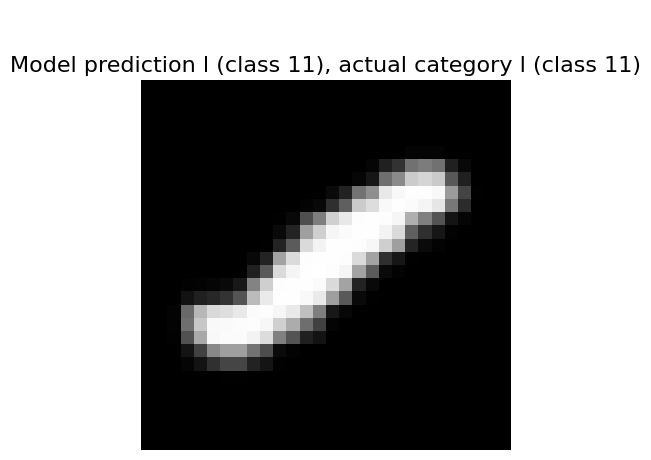

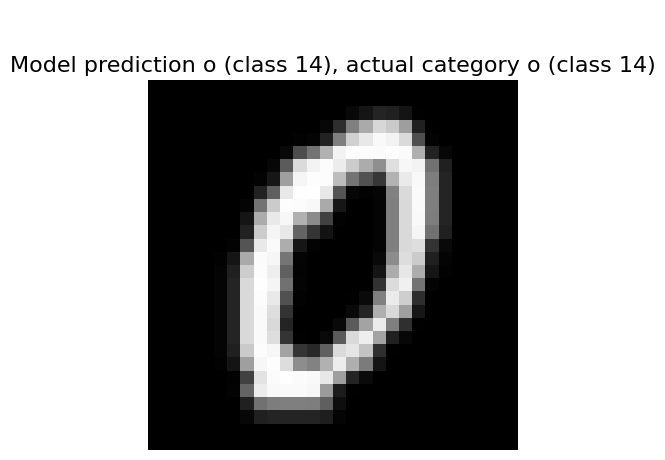

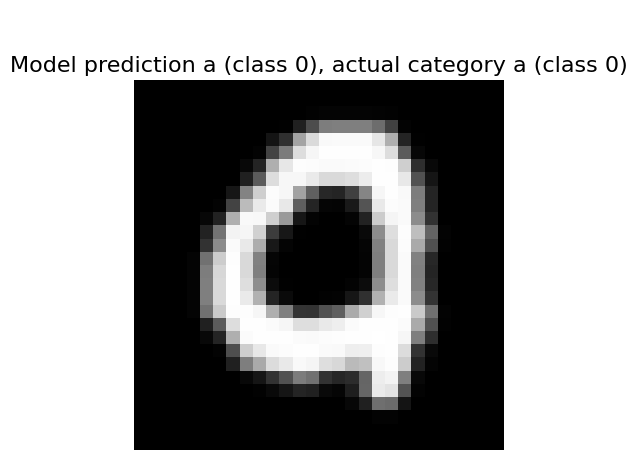

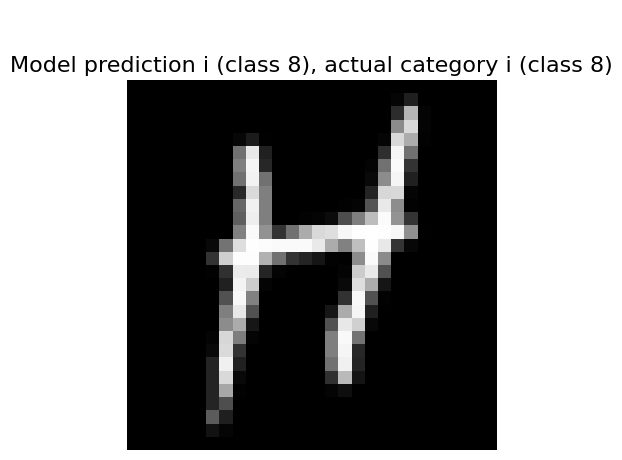

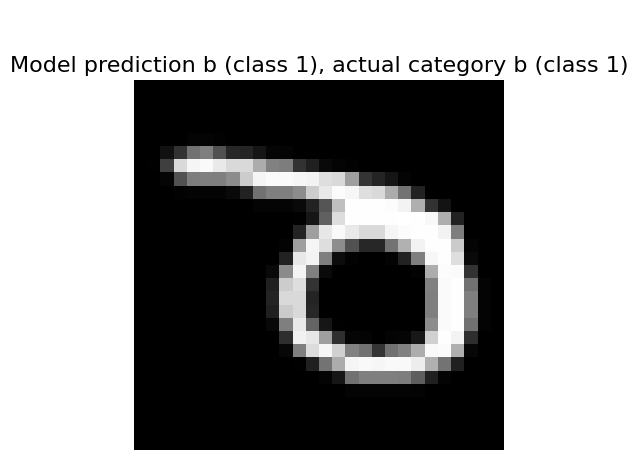

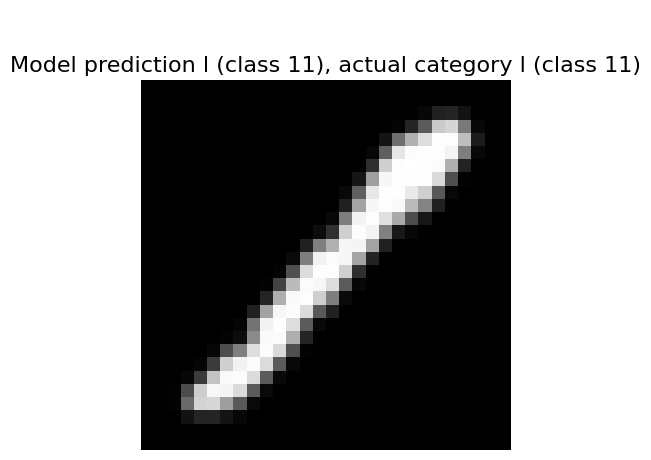

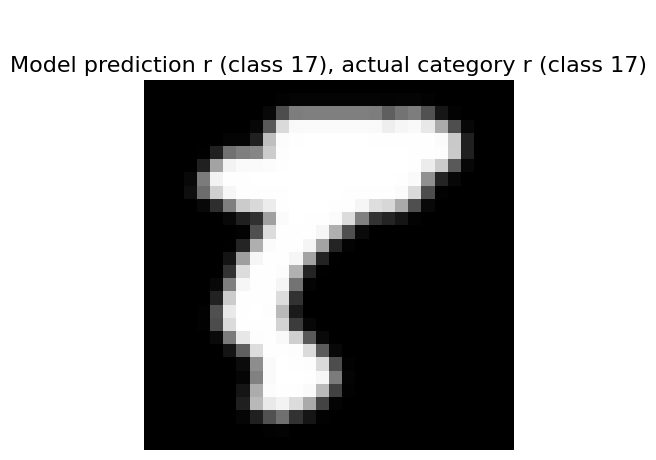

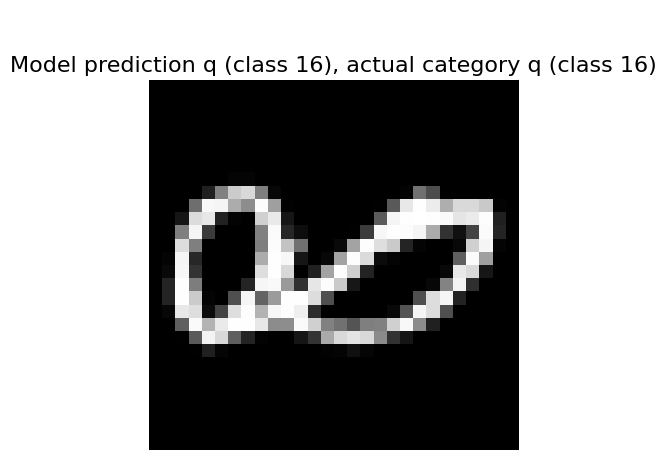

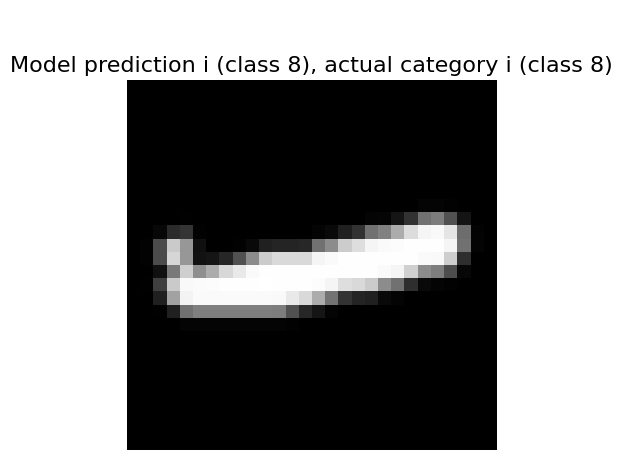

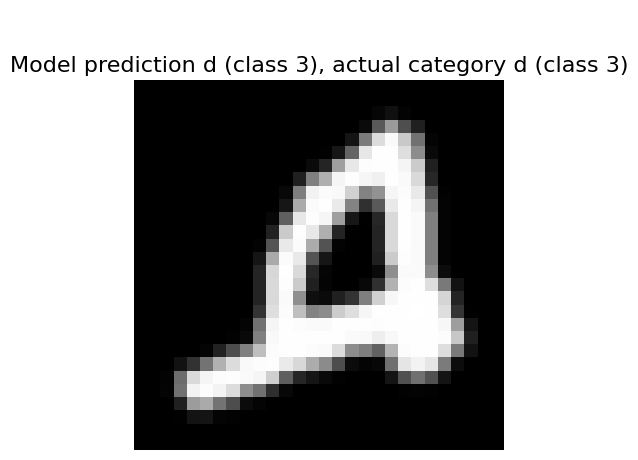

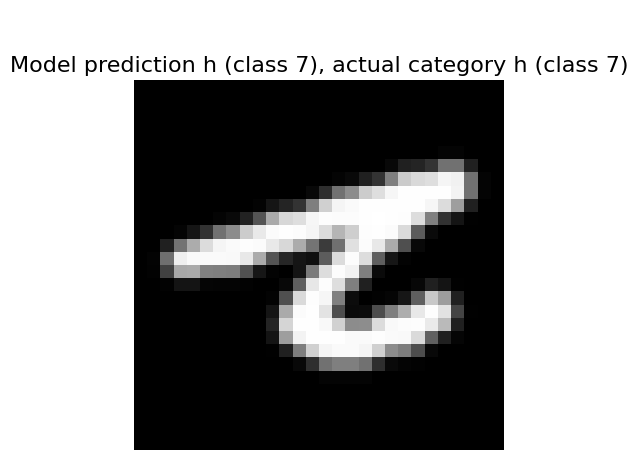

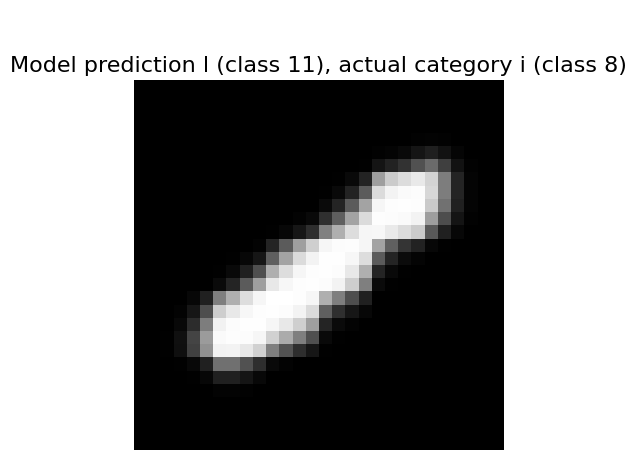

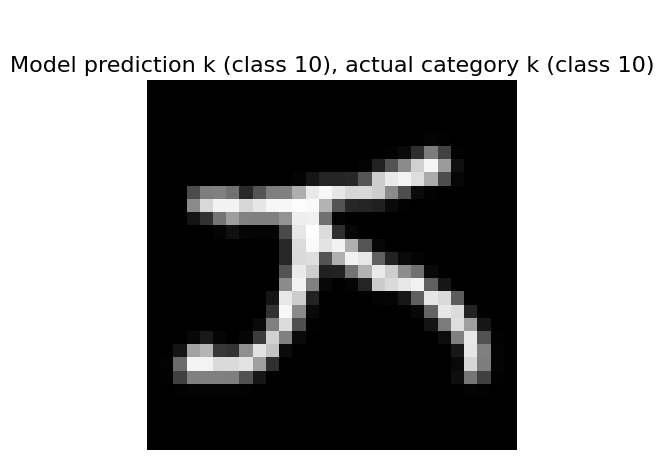

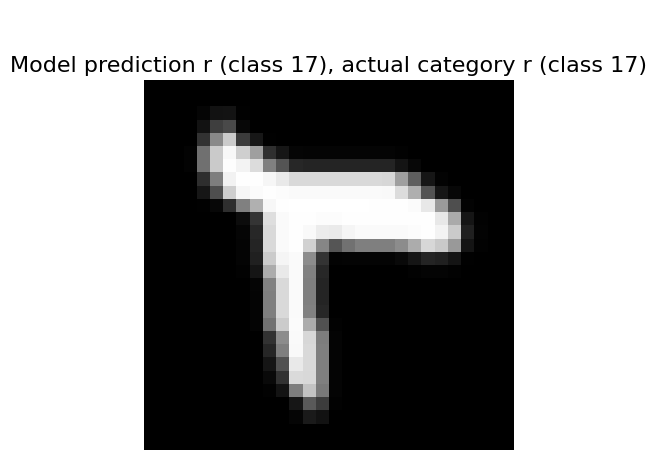

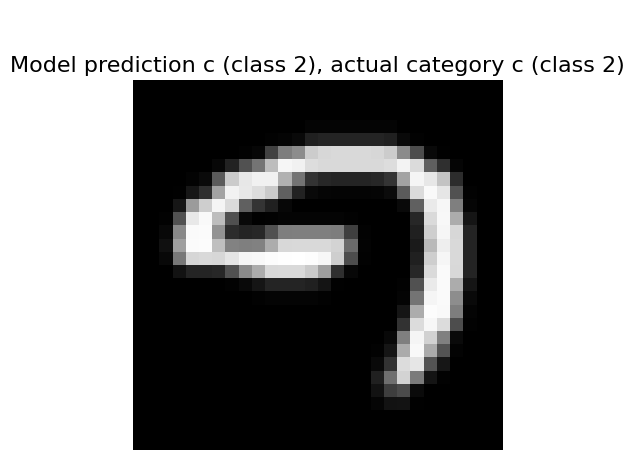

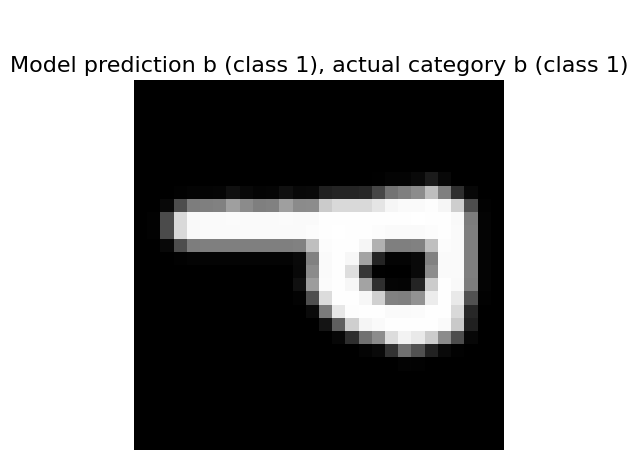

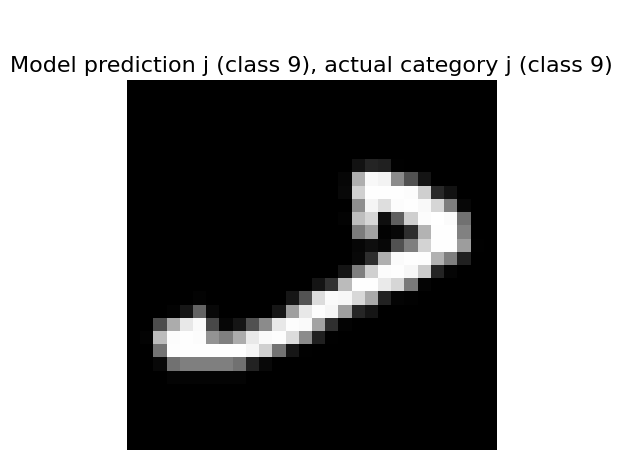

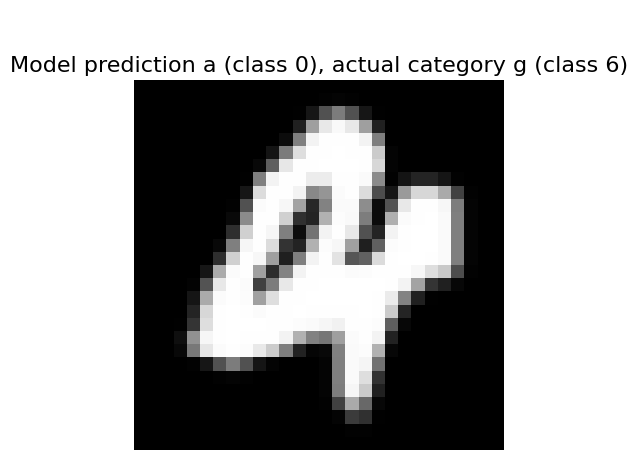

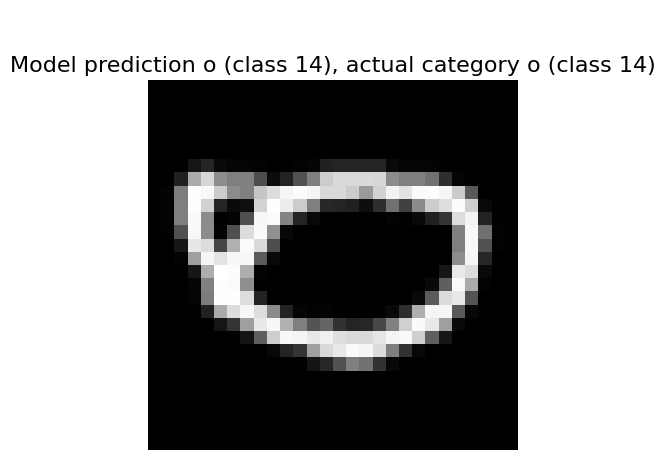

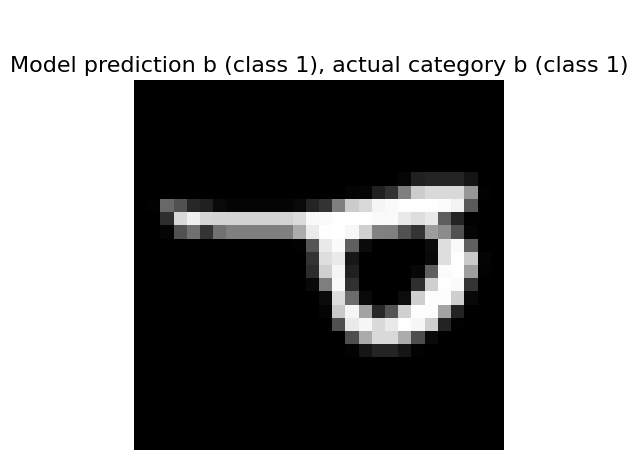

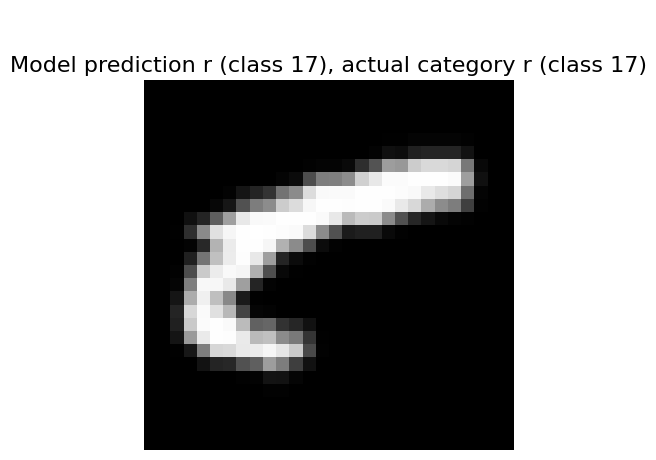

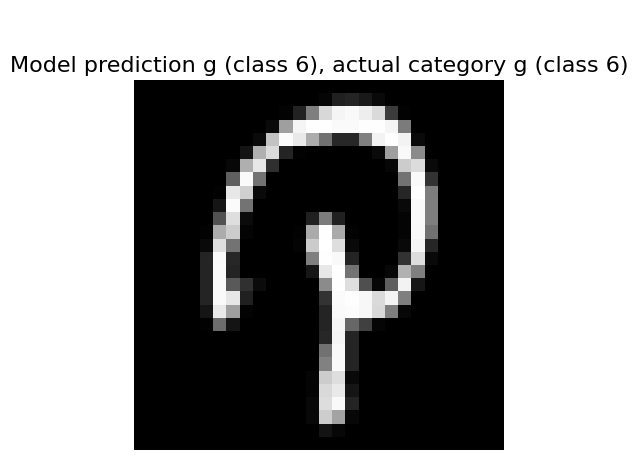

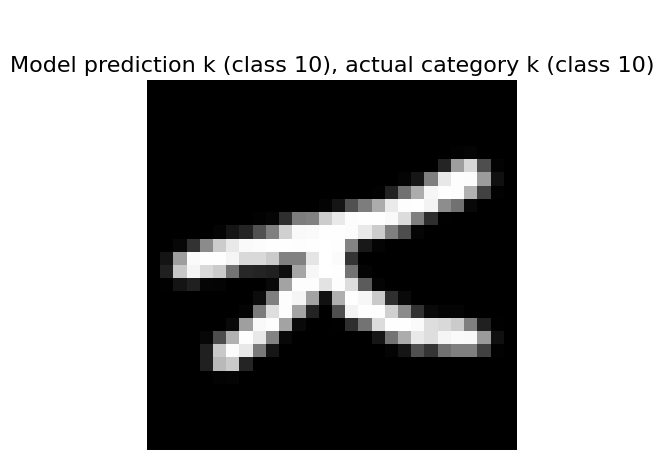

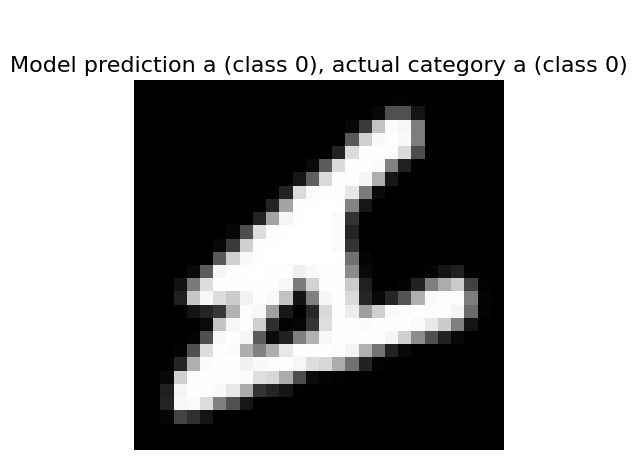

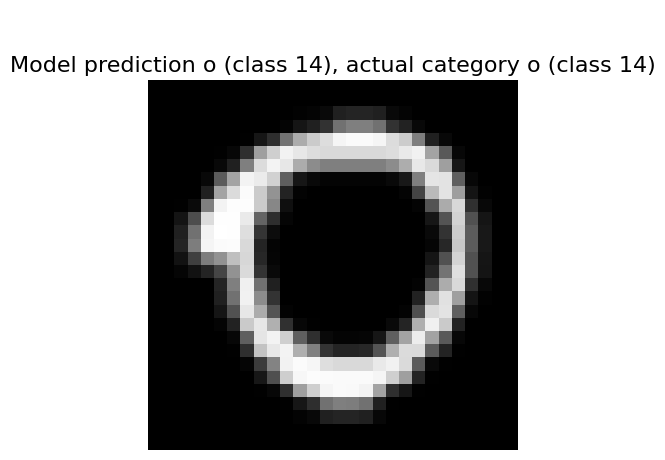

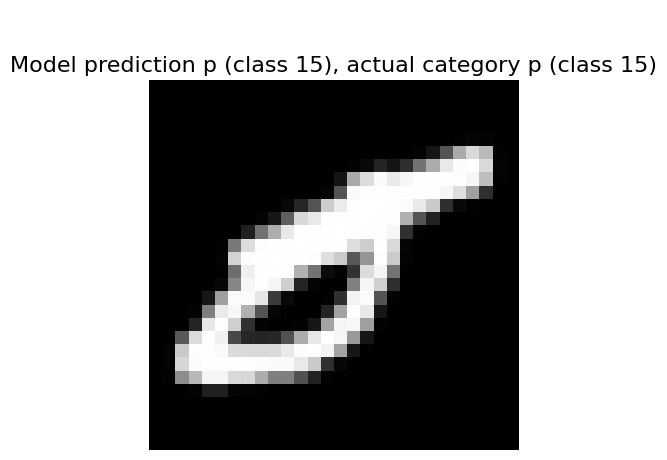

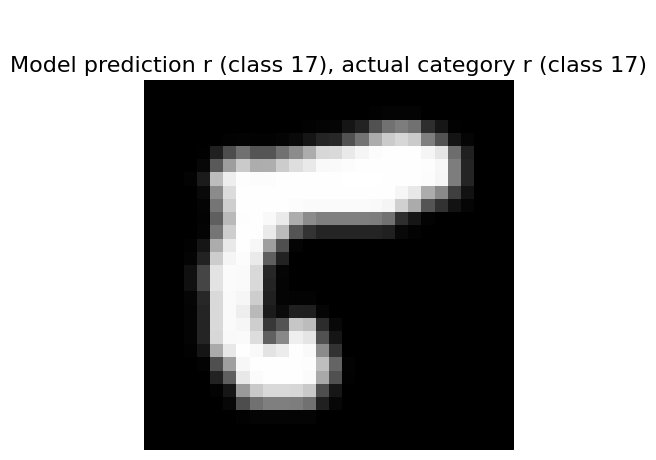

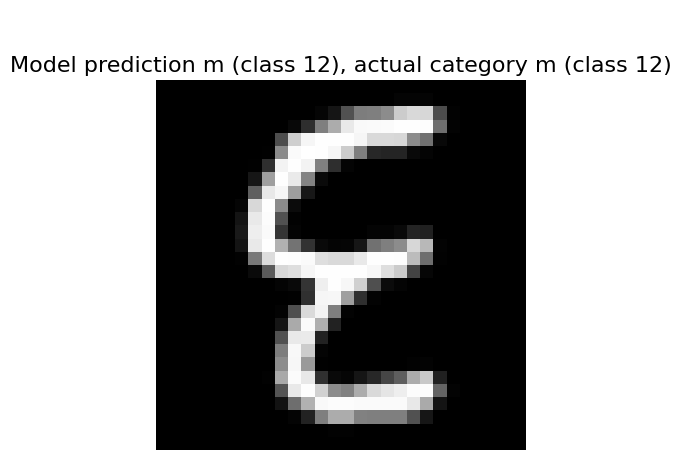

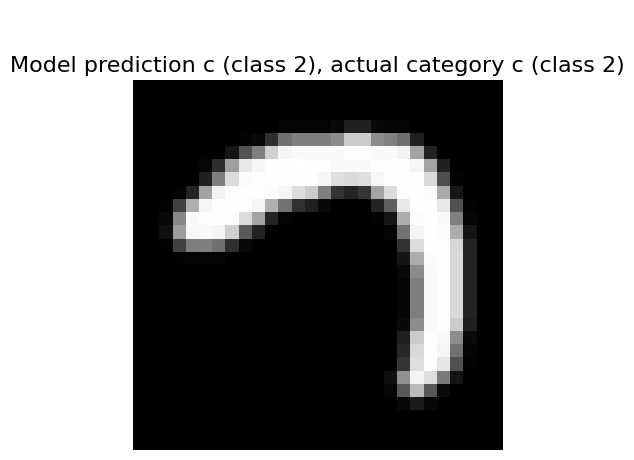

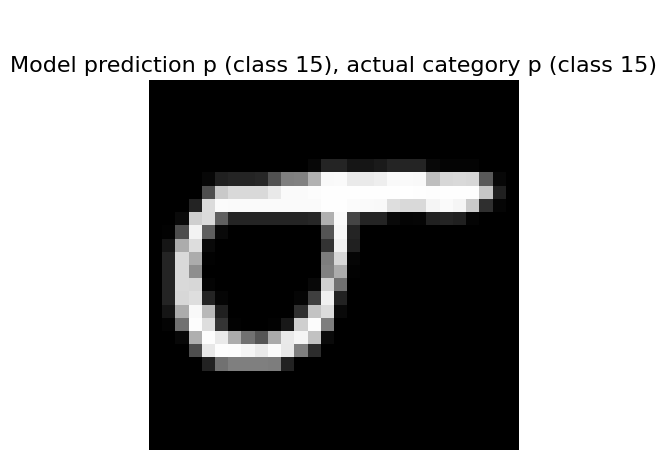

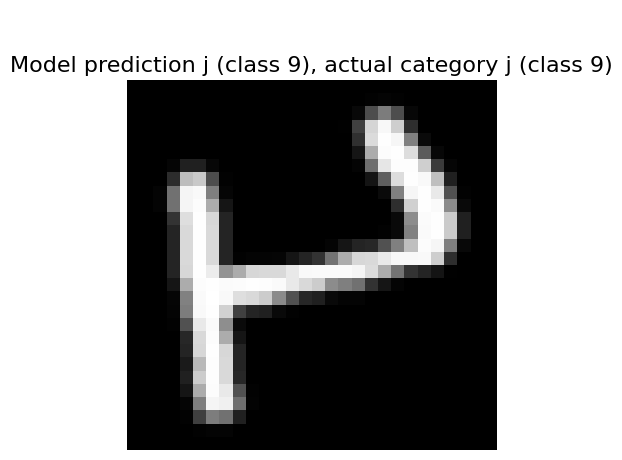

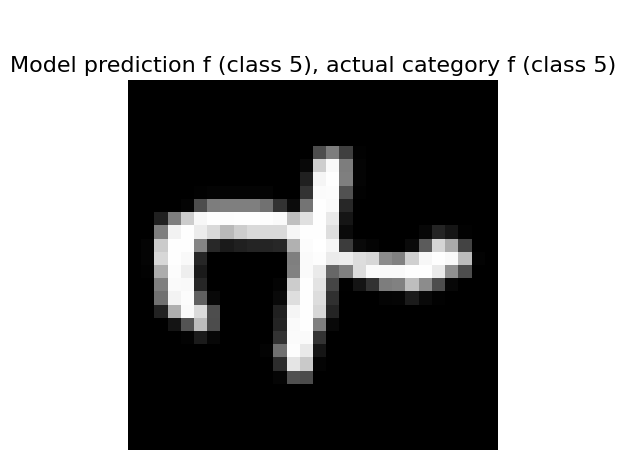

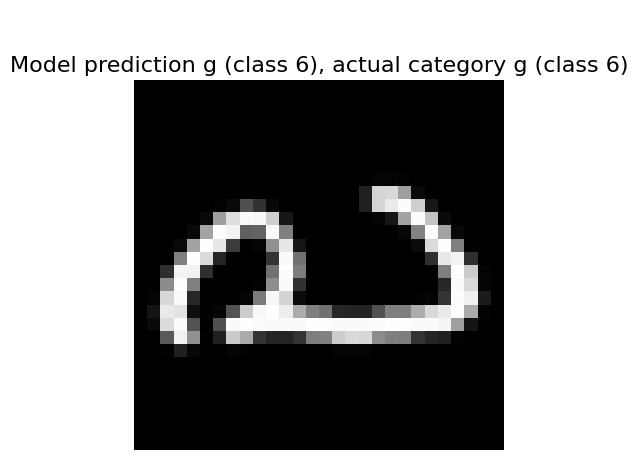

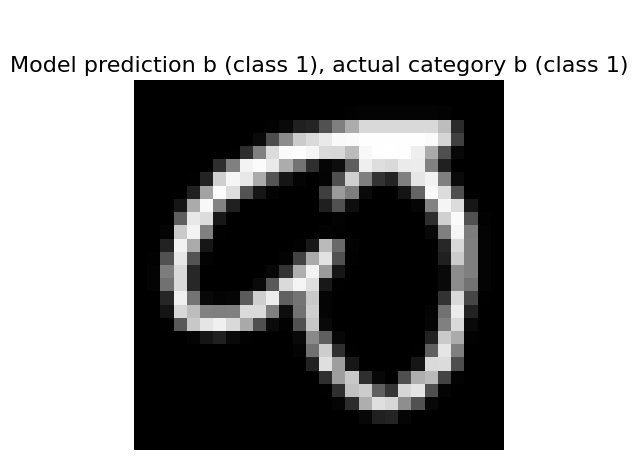

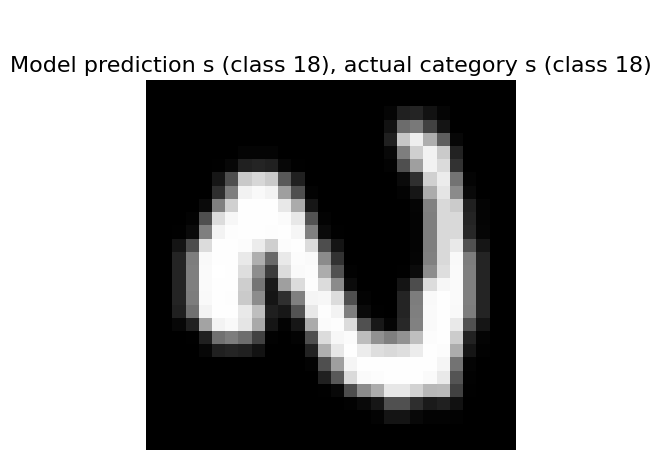

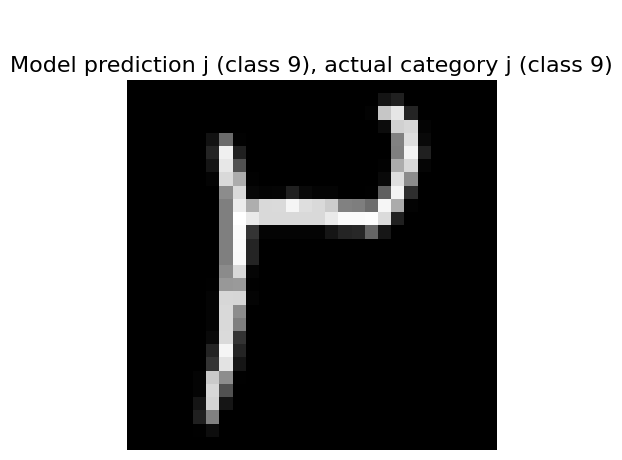

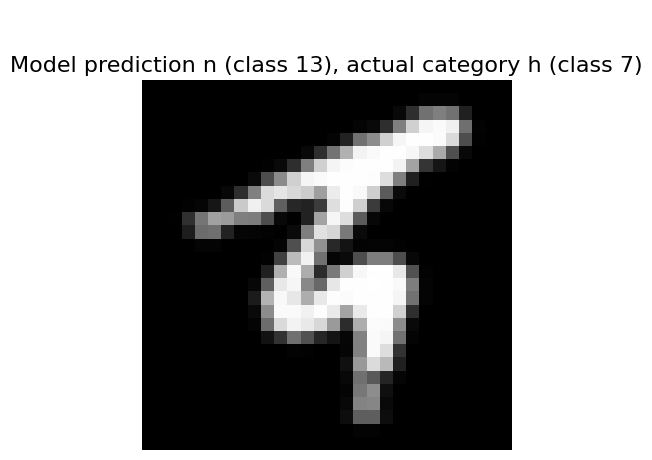

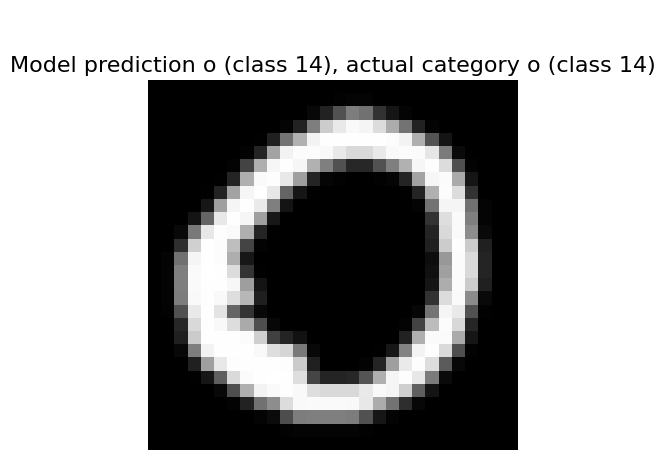

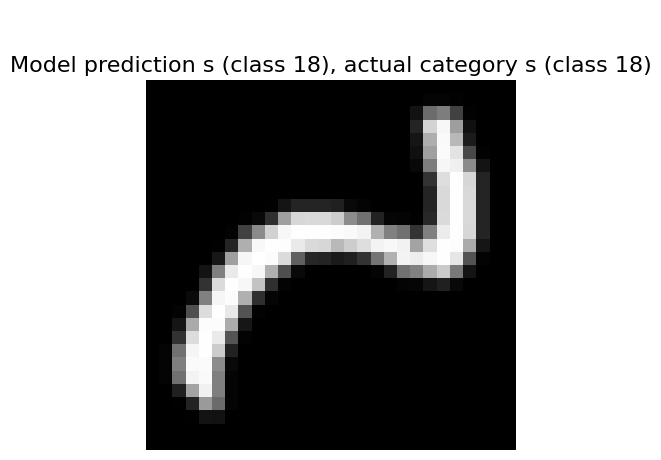

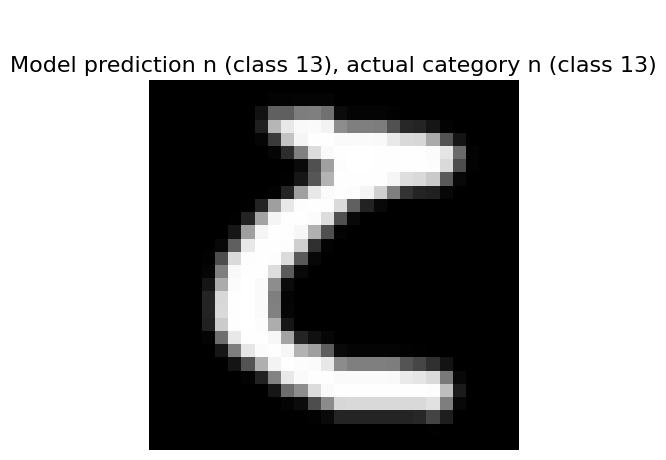

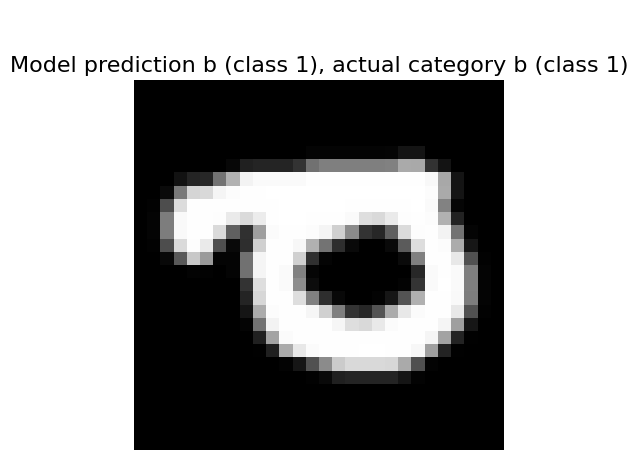

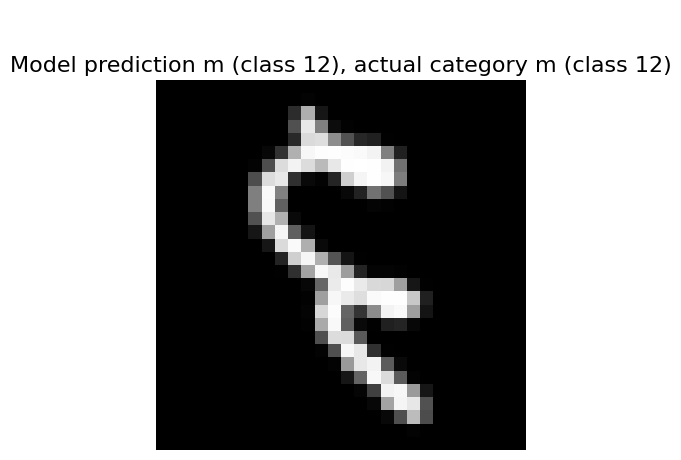

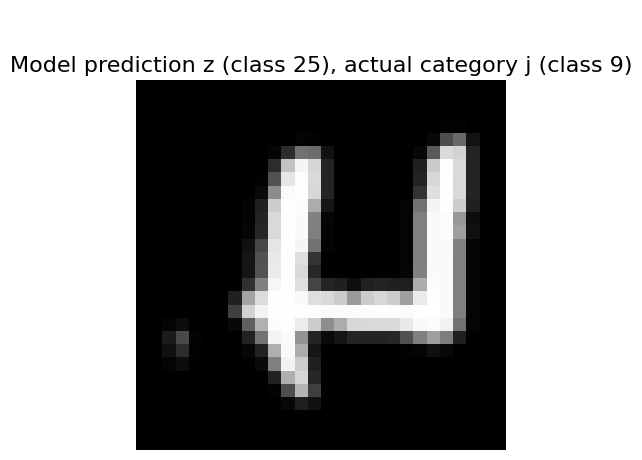

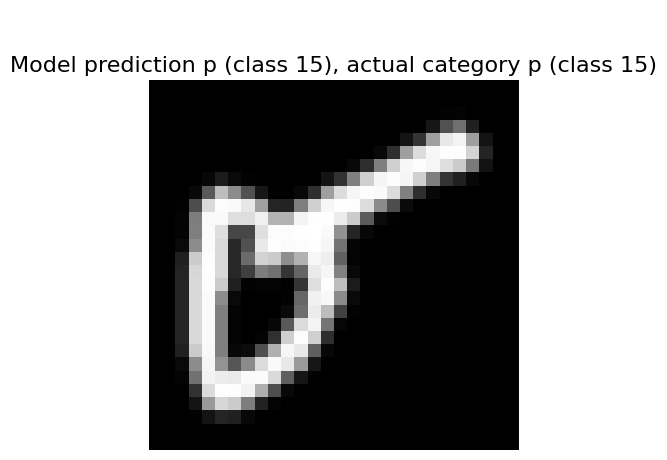

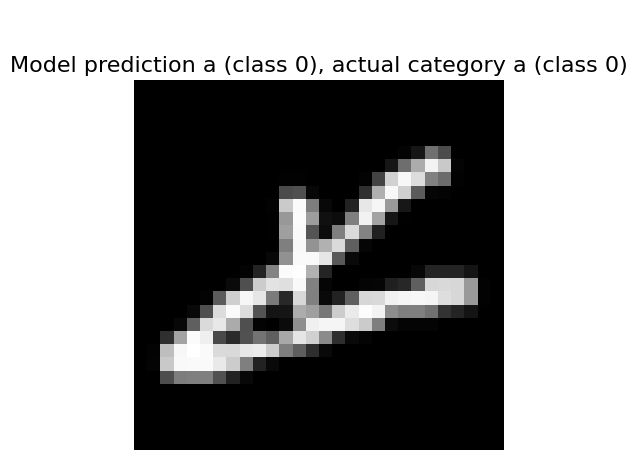

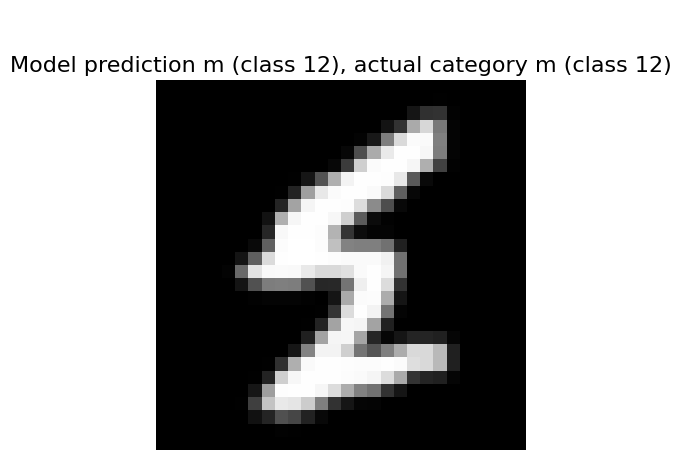

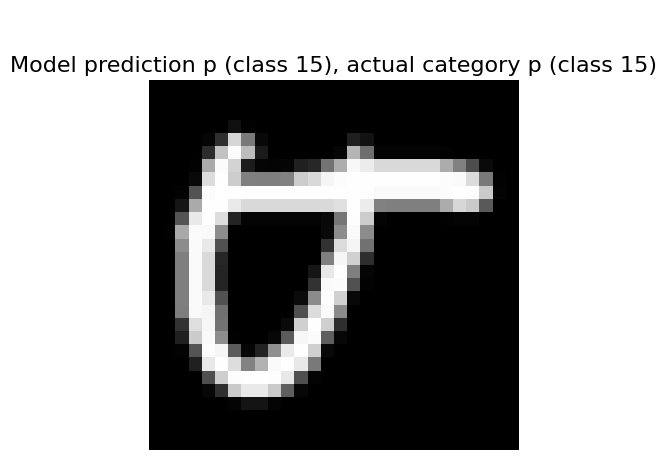

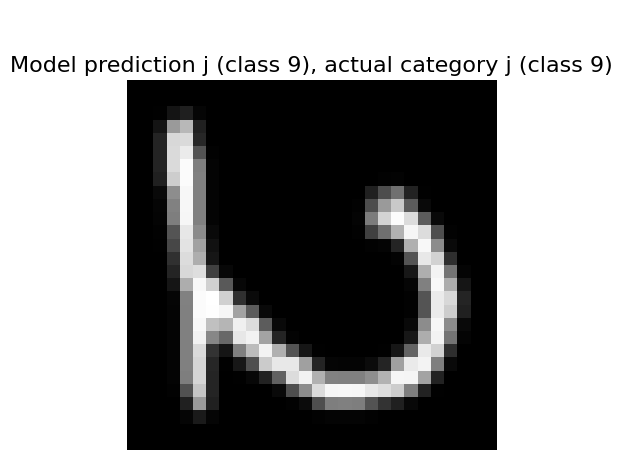

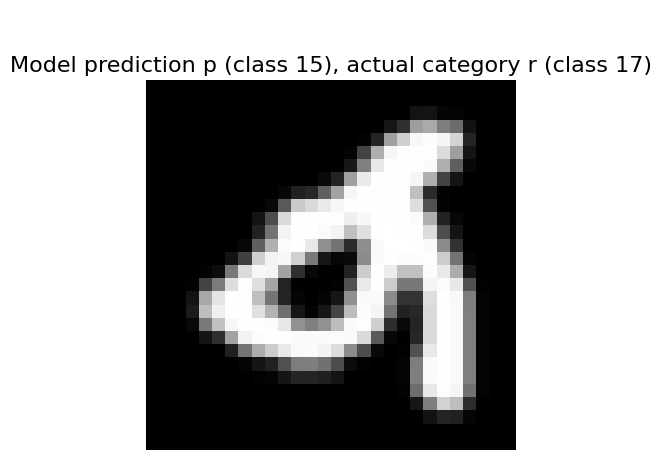

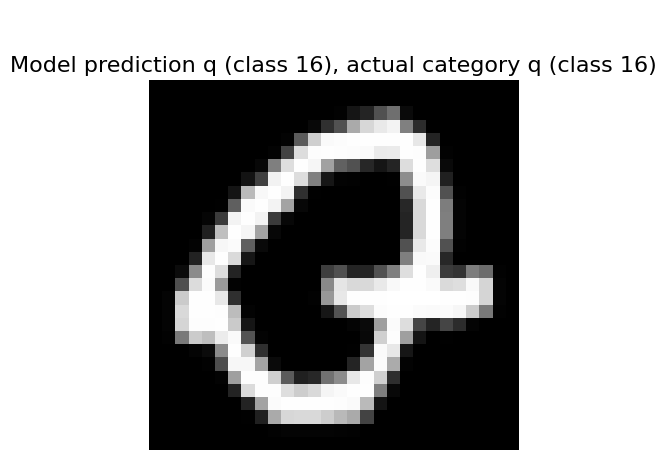

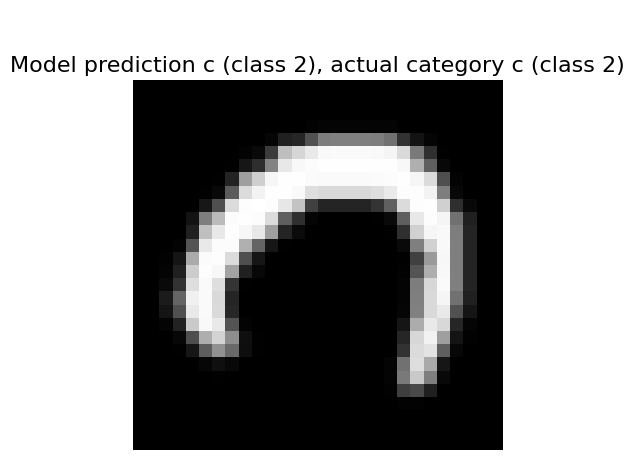

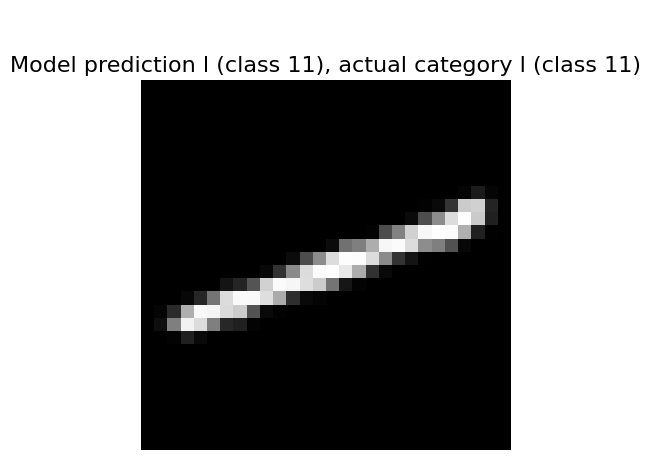

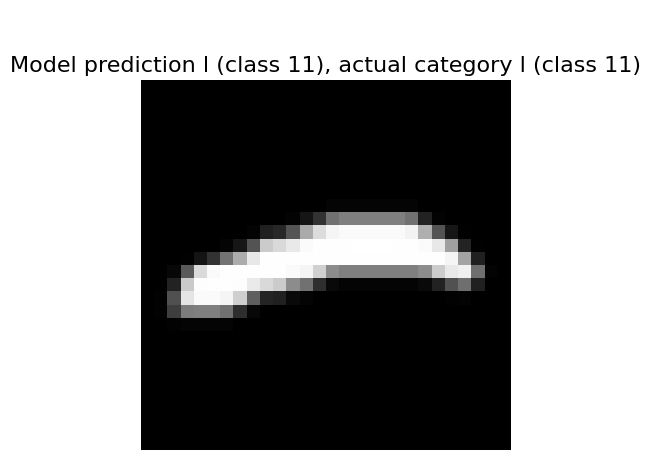

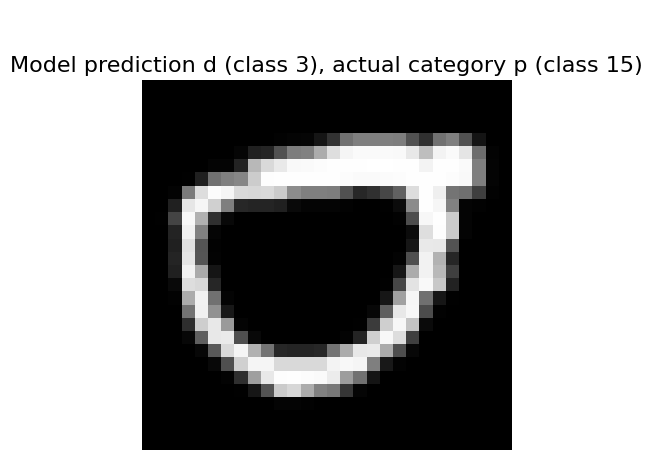

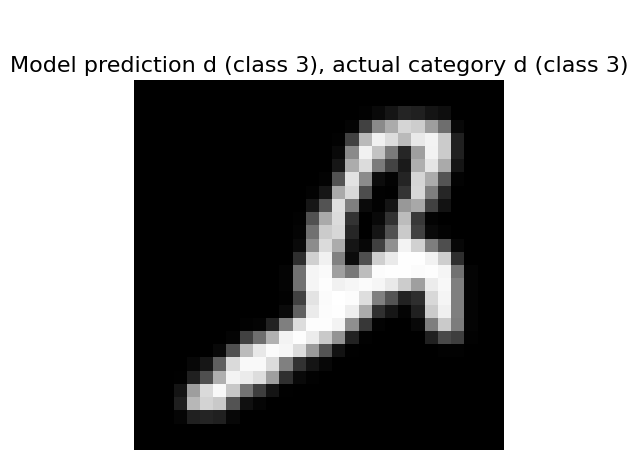

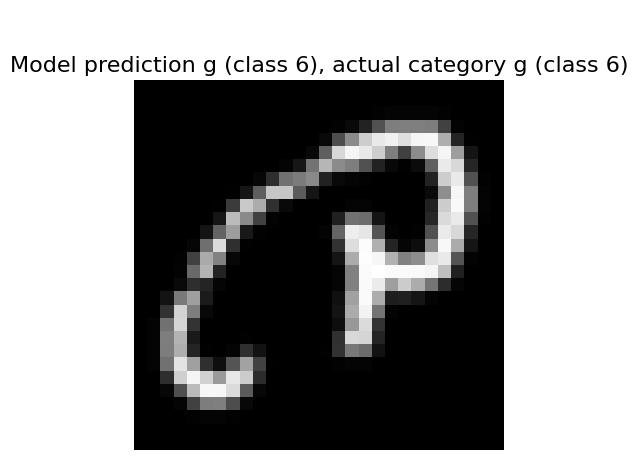

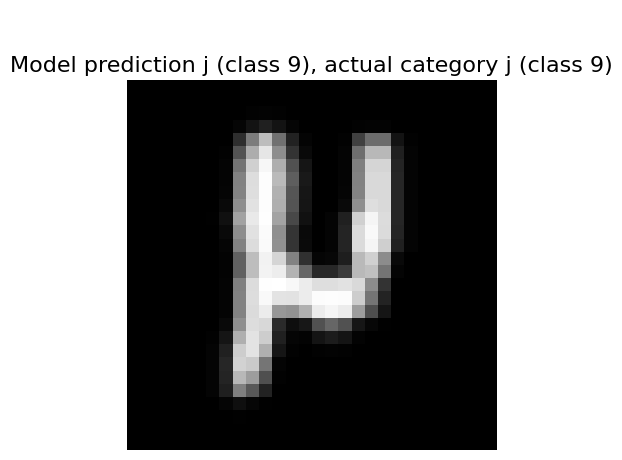

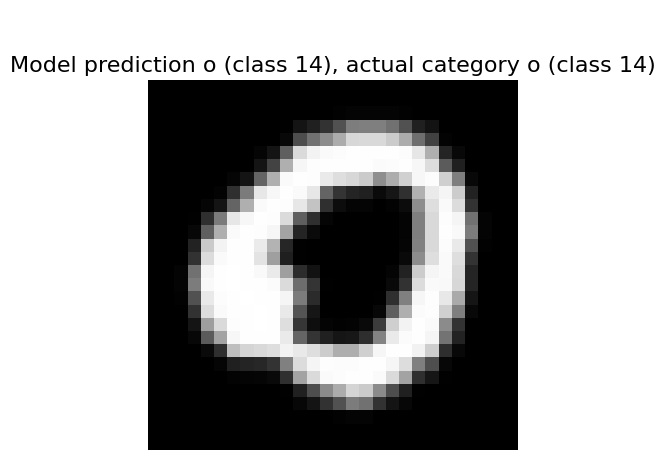

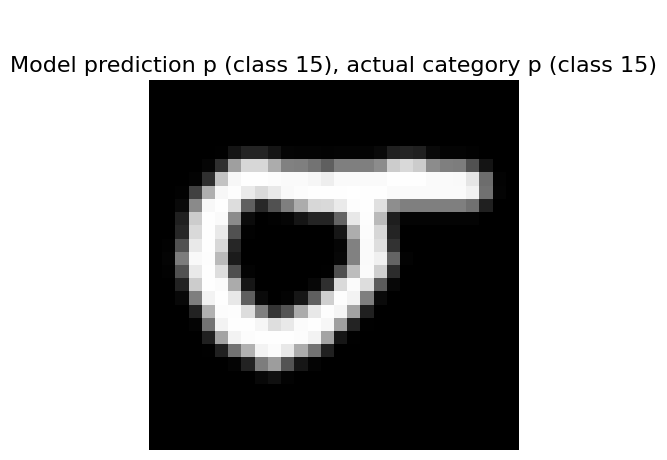

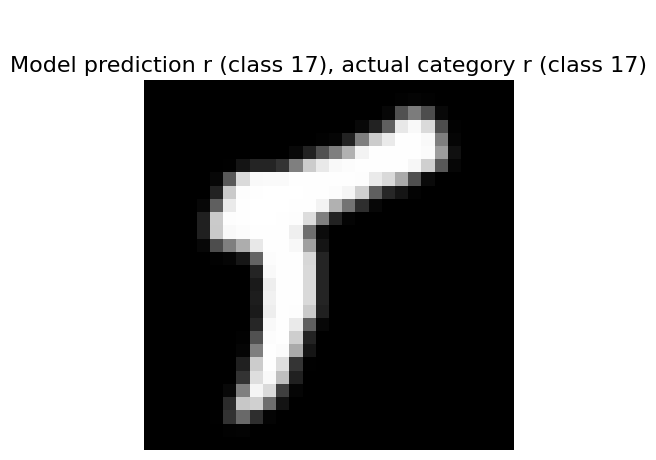

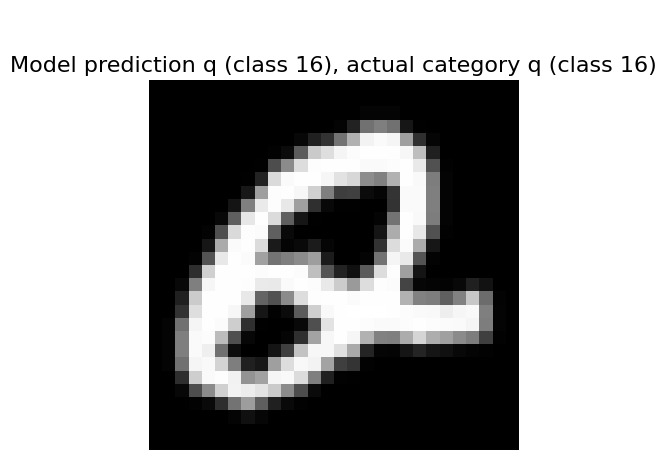

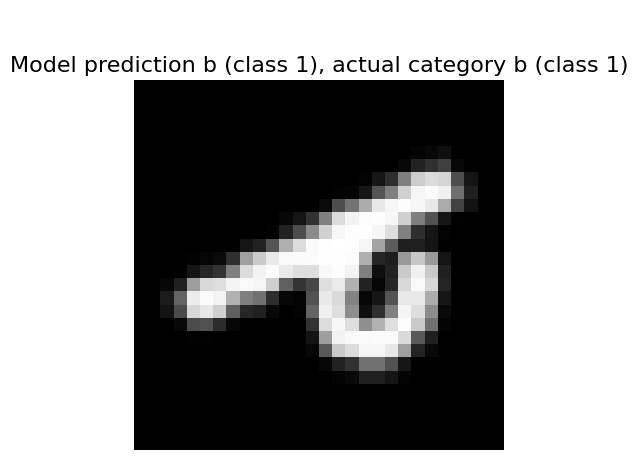

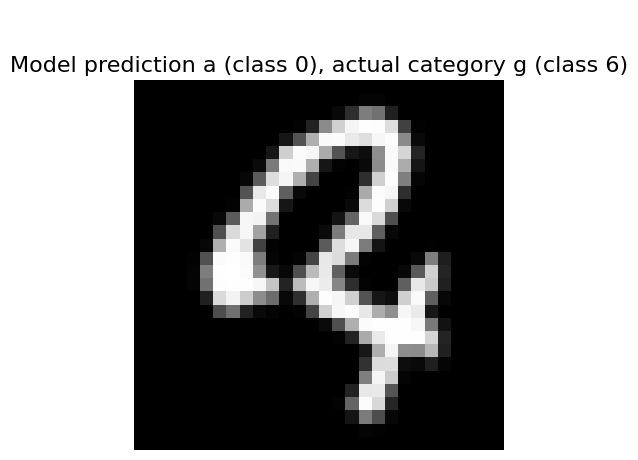

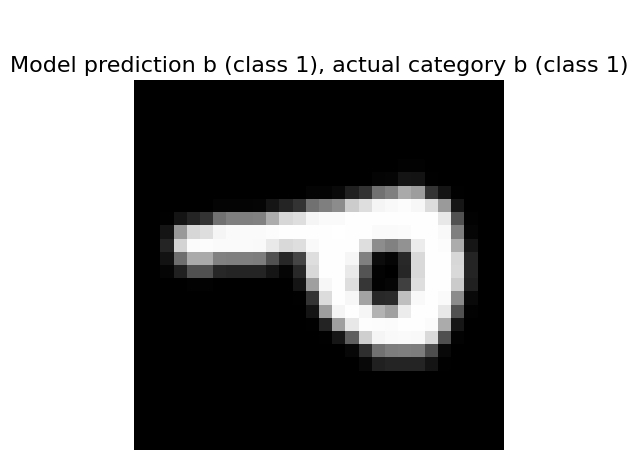

In [31]:
for i in range(64):
    predicted_class = np.argmax(predictions[i])
    actual_class = test_labels[i].long().item()-1

    show(i, "Model prediction {} (class {}), actual category {} (class {})".format(
          classes[predicted_class], predicted_class,
          classes[actual_class], actual_class
    ))

Accuracy on test data: 0.9172972972972973


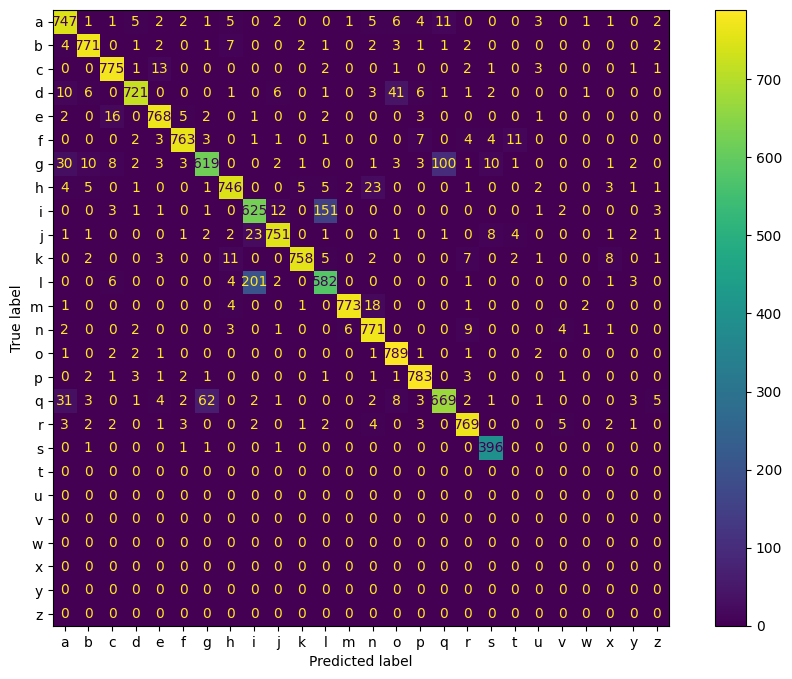

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = []
y_true = []

for inputs, labels in test_dataloader:
        output = loaded_model.predict(inputs.numpy().reshape(-1, 1, 28, 28))

        output = np.argmax(output, axis = 1).astype("float64").tolist()
        y_pred.extend(output)

        labels = [ x-1 for x in labels.tolist()]
        y_true.extend(labels)

acc = accuracy_score(y_true, y_pred)
print('Accuracy on test data:', acc)

cm = confusion_matrix(y_true, y_pred)
cmp = ConfusionMatrixDisplay(cm, display_labels = classes)

fig, ax = plt.subplots(figsize = (12, 8))
cmp.plot(ax = ax)

Just checking the test accuracy manually which is same as obtained by trainer.test

In [33]:
np.trace(cm) / len(test_dataset)

np.float64(0.9172972972972973)

Defining the search space for hyperparameters using Hyperopt.
we are tuning learning rate, and l1 and l2 which are input and output size for Linear layers coming in deep layers

In [34]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 37.3 MB/s eta 0:00:00


In [43]:
import optuna
from optuna.samplers import TPESampler
import math

LR_LOW = math.exp(-10)
LR_HIGH = math.exp(-8)

L1_CHOICES = [32, 64, 128]
L2_CHOICES = [64, 128, 256]

Defining the Lightning Module for tuning. Using save_hyperparameters() within your LightningModule’s __init__ method. It will enable Lightning to store all the provided arguments under the self.hparams attribute. These hyperparameters will also be stored within the model checkpoint, which simplifies model re-instantiation after training.

In [44]:
import pytorch_lightning as pl

class EmnistModel(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)

        self.criterion = nn.CrossEntropyLoss()

        self.network = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(256*7*7, self.hparams["l1"]),
            nn.ReLU(),
            nn.Linear(self.hparams["l1"], self.hparams["l2"]),
            nn.ReLU(),
            nn.Linear(self.hparams["l2"], 26)
        )

    def forward(self, xb):
        return self.network(xb.reshape(-1, 1, 28, 28))

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr = self.hparams["lr"])

    def training_step(self, batch, batch_idx):
        x, y = batch
        y -= 1

        y_hat = self(x)
        loss = self.criterion(y_hat, y.long())
        pred = y_hat.argmax(dim = 1)

        acc = accuracy(pred, y, task = "multiclass", num_classes = 26)

        self.log("train_loss", loss, on_epoch = True)
        self.log("train_acc", acc, on_epoch = True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y -= 1

        y_hat = self(x)
        loss = self.criterion(y_hat, y.long())
        pred = y_hat.argmax(dim = 1)

        acc = accuracy(pred, y, task = "multiclass", num_classes = 26)

        self.log("valid_loss", loss, on_epoch = True)
        self.log("valid_acc", acc, on_epoch = True)

        return acc

    def test_step(self, batch, batch_idx):
        x, y = batch
        y -= 1

        y_hat = self(x)
        loss = self.criterion(y_hat, y.long())
        pred = y_hat.argmax(dim = 1)

        acc = accuracy(pred, y, task = "multiclass", num_classes = 26)

        self.log("test_loss", loss)
        self.log("test_acc", acc)

        return acc

    def predict_step(self, batch, batch_idx, dataloader_idx = 0):
        x, y = batch

        return self(x)

Model Training objective is defined with -valid accuracy to be minimised i.e valid accuracy to be maximised. We are also using callback_metrics method from trainer to obtain losses and accuracies and then later on logging them using mlflow. We are also logging model for each run with Model signature same as defined earlier

In [45]:
from mlflow.models.signature import ModelSignature
from mlflow.types.schema import Schema, TensorSpec

def objective(trial: optuna.Trial):
    params = {
        "lr": trial.suggest_float("lr", LR_LOW, LR_HIGH, log=True),
        "l1": trial.suggest_categorical("l1", L1_CHOICES),
        "l2": trial.suggest_categorical("l2", L2_CHOICES),
    }

    with mlflow.start_run(nested=True):
        model = EmnistModel(params)

        trainer = pl.Trainer(max_epochs=5, accelerator="gpu")
        trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

        train_loss = trainer.callback_metrics["train_loss"].item()
        train_acc  = trainer.callback_metrics["train_acc"].item()
        valid_loss = trainer.callback_metrics["valid_loss"].item()
        valid_acc  = trainer.callback_metrics["valid_acc"].item()

        mlflow.log_params(params)
        mlflow.log_metrics({
            "train_loss_avg": train_loss, "train_acc_avg": train_acc,
            "valid_loss_avg": valid_loss, "valid_acc_avg": valid_acc
        })

        input_schema = Schema([TensorSpec(np.dtype(np.float32), (-1, 1, 28, 28))])
        output_schema = Schema([TensorSpec(np.dtype(np.float32), (-1, 26))])
        signature = ModelSignature(inputs=input_schema, outputs=output_schema)

        mlflow.pytorch.log_model(model, "emnist-letters-classifier-cnn-model-01", signature=signature)

        return -valid_acc

In [46]:
with mlflow.start_run():
    study = optuna.create_study(direction="minimize", sampler=TPESampler())
    study.optimize(objective, n_trials=5)

best_result = study.best_trial.params

[I 2026-02-09 08:53:40,530] A new study created in memory with name: no-name-bfae5a8f-28f7-4d34-aa13-0e787680e3fe
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026/02/09 08:53:40 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/pytorch/_lightning_autolog.py:542: UserWarning: Autologging is known to be compatible with pytorch-lightning versions between 2.1.4 and 2.6.0 and may not succeed with packages outside this range."
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try ins

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ network   │ Sequential       │  2.0 M │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.0 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026/02/09 08:54:11 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 
'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored 
metric value is not available.

...

2026/02/09 09:06:59 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 
'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored 
metric value is not available.

2026/02/09 09:07:35 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 
'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored 
metric value is not available.

2026/02/09 09:08:09 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 
'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored 
metric value is not available.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


2026/02/09 09:08:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/09 09:08:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/02/09 09:08:10 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.9.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/09 09:08:23 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.24.0+cu126) contains a local version label (+cu1

### TODO Recording:

- As the hyperparameter tuning is running go to the MLflow UI
- Select the current experiment
- Show that the outer run appears with a +, expand and show the inner srun
- Click on the + next to the metrics and add test_acc, train_acc, valid_acc
- Stay on the page and hit refresh till 2-3 runs complete
- Click through to a run and show the metrics there
- Come back to the main experiments page and click on refresh
- Click on Chart and hide all EXCEPT 2 runs
- Show how we can compare those two runs in the charts - show all the charts with this comparison


Best set of parameters are obatined

In [48]:
best_result

{'lr': 0.00025544381333144435, 'l1': 128, 'l2': 64}

In [47]:
print(best_result)

{'lr': 0.00025544381333144435, 'l1': 128, 'l2': 64}


### TODO Recording:

- Go to the MLflow UI
- Sort the runs by valid_acc (should be a column on the experiments page, we added it earlier)
- Sort in descending order
- Find the model with the best validation accuracy
- Click through and show the parameters of the model
- Select the model directory under artifacts
- Copy over the run ID for predictions


In [49]:
import mlflow
logged_model = 'runs:/a1d349a35d984cad99c19cc4ade63b6f/emnist-letters-classifier-cnn-model-01'

loaded_model = mlflow.pyfunc.load_model(logged_model)

predictions = loaded_model.predict(test_imgs.numpy().reshape(-1, 1, 28, 28))

predictions[:5]

array([[ -7.5123644 , -10.022287  ,  -2.6207073 ,  -1.5858502 ,
         -7.7763968 ,  -6.264547  ,  -5.801234  ,  -4.387059  ,
          7.8124423 ,  -0.76592773,  -4.5256534 ,   6.0833035 ,
        -16.028193  ,  -0.36144376,  -6.6482673 ,  -0.6179933 ,
         -5.291619  ,   1.0046767 , -10.258542  ,  -0.18309772,
         -4.590306  ,   1.8219045 ,  -5.9497337 ,  -5.706564  ,
          0.8243177 ,  -9.166572  ],
       [  1.1357162 ,  -2.4803712 ,   2.1489997 ,   0.84033465,
          2.078846  ,  -3.4280155 ,  -0.53543025,  -7.8934107 ,
         -7.4641004 ,  -1.4992117 ,  -8.251226  ,  -7.2658057 ,
         -7.9419184 ,  -3.084477  ,   7.5406795 ,  -1.7228984 ,
          2.1990232 ,  -3.1375992 ,  -0.61912286,  -3.2026408 ,
         -5.476672  , -11.421317  ,  -9.113651  ,  -8.266238  ,
         -3.667586  ,  -4.732967  ],
       [  5.545277  ,  -5.32624   ,   2.985028  ,  -1.3398774 ,
         -1.2139252 ,  -7.9101458 ,   0.05551189,  -7.5057364 ,
         -7.5636897 ,  -3.4954

For whole test data, predictions are obtained and accuracy is checked which is bit higher than untuned model

In [50]:
from sklearn.metrics import accuracy_score

y_pred = []
y_true = []

for inputs, labels in test_dataloader:
        output = loaded_model.predict(inputs.numpy().reshape(-1, 1, 28, 28))

        output = np.argmax(output, axis = 1).astype('float64').tolist()
        y_pred.extend(output)

        labels = [ x-1 for x in labels.tolist()]
        y_true.extend(labels)

acc = accuracy_score(y_true, y_pred)
print('Accuracy on test data:', acc)

Accuracy on test data: 0.8994594594594595


### TODO Recording:

- Go back to the MLflow UI - where you should have the page for the best model open
- Select the artifacts directory and "Register this model"
- Model name: emnist_cnn_classification
- Go to the Models tab in the UI
- Show version 1 of the model is registered
- Click through and show the model
- Change the Stage of the model to "Staging"
- Change the Stage of the model to "Production"

